# Class 11: Support Vector Machine & Cross Validation

---
## 1. Load & Explore Data

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target

# Breast Cancer Wisconsin default: 1=no Cancer, 0=Cancer
# We flip it to: 1=Cancer, 0=No Cancer
y = 1 - y

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print('Dataset shape  :', X.shape)
print('Features       :', X.shape[1])
print('Samples        :', X.shape[0])
print()
print('Class distribution:')
print(f'  Cancer    (1) : {(y == 1).sum()} samples')
print(f'  No Cancer (0) : {(y == 0).sum()} samples')

Dataset shape  : (569, 30)
Features       : 30
Samples        : 569

Class distribution:
  Cancer    (1) : 212 samples
  No Cancer (0) : 357 samples


---
## 2. Preprocessing — Train/Test Split & Feature Scaling

> ⚠️ **SVM is sensitive to feature scale.**  
> If one feature has a much larger range than others, it will dominate the decision boundary.  
> Always scale features before fitting SVM.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size :', X_train.shape[0])
print('Test size  :', X_test.shape[0])

Train size : 455
Test size  : 114


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

---
## 3. SVM with Different Kernels

In [10]:
from sklearn.svm import SVC

kernels = ['linear', 'rbf', 'poly']
results = {}

for kernel in kernels:
    model = SVC(kernel=kernel, C=1.0, random_state=42)
    model.fit(X_train_scaled, y_train)
    acc = model.score(X_test_scaled, y_test)
    results[kernel] = acc
    print(f'Kernel: {kernel:<8}  Accuracy: {acc:.4f}')

Kernel: linear    Accuracy: 0.9649
Kernel: rbf       Accuracy: 0.9737
Kernel: poly      Accuracy: 0.8860


In [11]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

best_kernel = max(results, key=results.get)
print(f'Best kernel: {best_kernel}')

best_model = SVC(kernel=best_kernel, C=1.0, random_state=42)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=['No Cancer (0)', 'Cancer (1)']))

Best kernel: rbf
               precision    recall  f1-score   support

No Cancer (0)       0.96      1.00      0.98        72
   Cancer (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



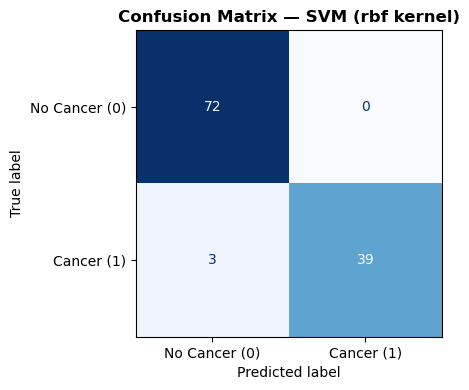

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Cancer (0)', 'Cancer (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — SVM ({best_kernel} kernel)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Effect of C Parameter

> **C controls the trade-off between margin width and classification errors.**  
> - Small C → wide margin, more violations allowed → simpler model  
> - Large C → narrow margin, fewer violations → complex model

In [14]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_scores_c = []
test_scores_c  = []

for C in C_values:
    model = SVC(kernel='rbf', C=C, random_state=42)
    model.fit(X_train_scaled, y_train)
    train_scores_c.append(model.score(X_train_scaled, y_train))
    test_scores_c.append(model.score(X_test_scaled, y_test))

print(f'{"C":>8}  {"Train Acc":>10}  {"Test Acc":>10}')
print('-' * 32)
for C, tr, te in zip(C_values, train_scores_c, test_scores_c):
    print(f'{C:>8}  {tr:>10.4f}  {te:>10.4f}')

       C   Train Acc    Test Acc
--------------------------------
   0.001      0.6264      0.6316
    0.01      0.6264      0.6316
     0.1      0.9538      0.9474
       1      0.9868      0.9737
      10      0.9890      0.9737
     100      1.0000      0.9649
    1000      1.0000      0.9649


---
## 5. Effect of Gamma Parameter

> **Gamma controls the influence radius of each training point (RBF kernel only).**  
> - Small gamma → smooth, broad boundary → far-reaching influence  
> - Large gamma → tight, complex boundary → local influence only

In [15]:
gamma_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
train_scores_g = []
test_scores_g  = []

for g in gamma_values:
    model = SVC(kernel='rbf', C=1.0, gamma=g, random_state=42)
    model.fit(X_train_scaled, y_train)
    train_scores_g.append(model.score(X_train_scaled, y_train))
    test_scores_g.append(model.score(X_test_scaled, y_test))

print(f'{"Gamma":>8}  {"Train Acc":>10}  {"Test Acc":>10}')
print('-' * 32)
for g, tr, te in zip(gamma_values, train_scores_g, test_scores_g):
    print(f'{g:>8}  {tr:>10.4f}  {te:>10.4f}')

   Gamma   Train Acc    Test Acc
--------------------------------
  0.0001      0.7846      0.7719
   0.001      0.9495      0.9386
    0.01      0.9758      0.9561
     0.1      0.9890      0.9298
       1      1.0000      0.6316
      10      1.0000      0.6316
     100      1.0000      0.6316


---
## 6. Cross Validation

### 6.1 The Problem — Single Split is Unreliable

In [16]:
model = SVC(kernel='rbf', C=1.0, random_state=42)
random_states = [42, 123, 100]
single_split_scores = []

for rs in random_states:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                               random_state=rs, stratify=y)
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    model.fit(X_tr_s, y_tr)
    acc = model.score(X_te_s, y_te)
    single_split_scores.append(acc)
    print(f'  random_state = {rs:>4}  →  Accuracy: {acc:.4f}')

  random_state =   42  →  Accuracy: 0.9737
  random_state =  123  →  Accuracy: 0.9561
  random_state =  100  →  Accuracy: 1.0000


### 6.2 K-Fold Cross Validation

In [18]:
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold

# Scale full dataset for CV
scaler_cv = StandardScaler()
X_scaled_full = scaler_cv.fit_transform(X)

model_cv = SVC(kernel='rbf', C=1.0, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = cross_val_score(model_cv, X_scaled_full, y, cv=kf, scoring='accuracy')

print('K-Fold Cross Validation (K=5):')
for i, score in enumerate(kf_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print()
print(f'  Mean  : {kf_scores.mean():.4f}')
print(f'  Std   : {kf_scores.std():.4f}')

K-Fold Cross Validation (K=5):
  Fold 1: 0.9737
  Fold 2: 0.9825
  Fold 3: 0.9737
  Fold 4: 0.9912
  Fold 5: 0.9735

  Mean  : 0.9789
  Std   : 0.0071


### 6.3 Stratified K-Fold — For Imbalanced Data

In [11]:
print(f'Original  →  Cancer: {y.mean()*100:.1f}%  |  No Cancer: {(1-y).mean()*100:.1f}%')
print()

print('--- Regular K-Fold ---')
kf_check = KFold(n_splits=5, shuffle=True, random_state=42)
for i, (_, test_idx) in enumerate(kf_check.split(X, y), 1):
    fold_y = y[test_idx]
    print(f'  Fold {i}: Cancer = {fold_y.mean()*100:.1f}%  |  No Cancer = {(1-fold_y).mean()*100:.1f}%')

print()
print('--- Stratified K-Fold ---')
skf_check = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for i, (_, test_idx) in enumerate(skf_check.split(X, y), 1):
    fold_y = y[test_idx]
    print(f'  Fold {i}: Cancer = {fold_y.mean()*100:.1f}%  |  No Cancer = {(1-fold_y).mean()*100:.1f}%')

Original  →  Cancer: 37.3%  |  No Cancer: 62.7%

--- Regular K-Fold ---
  Fold 1: Cancer = 37.7%  |  No Cancer = 62.3%
  Fold 2: Cancer = 32.5%  |  No Cancer = 67.5%
  Fold 3: Cancer = 37.7%  |  No Cancer = 62.3%
  Fold 4: Cancer = 37.7%  |  No Cancer = 62.3%
  Fold 5: Cancer = 40.7%  |  No Cancer = 59.3%

--- Stratified K-Fold ---
  Fold 1: Cancer = 37.7%  |  No Cancer = 62.3%
  Fold 2: Cancer = 37.7%  |  No Cancer = 62.3%
  Fold 3: Cancer = 36.8%  |  No Cancer = 63.2%
  Fold 4: Cancer = 36.8%  |  No Cancer = 63.2%
  Fold 5: Cancer = 37.2%  |  No Cancer = 62.8%
